In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from kneed import KneeLocator 

In [2]:
MONOPOLY_XLSX ='Base_clientes_Monopoly.xlsx'
MONOPOLY_CSV ='Base_clientes_Monopoly_otro.csv'

try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

df = pd.read_excel(MONOPOLY_XLSX)
df.head(10)

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,ColMx_T01,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target
0,1,160,M,13.0,43,NaN,130,1,1,0,...,0.0,33000,0.0,1099866.0,0.0,1099866.0,15080,0.0,R,0
1,2,160,H,13.0,46,143640.0,69,1,0,0,...,0.0,300000,0.0,214592.0,0.0,214592.0,83596,0.0,R,0
2,3,170,H,13.0,45,929106.0,24,1,1,0,...,0.0,216676,0.0,0.0,0.0,7400.0,0,0.0,T,0
3,4,151,H,13.0,46,172447.0,134,0,1,0,...,0.0,60000,0.0,272762.0,0.0,272762.0,10591,0.0,R,0
4,5,170,H,13.0,46,805250.0,116,0,1,1,...,0.0,272925,0.0,249562.0,0.0,75339.0,377782,0.0,R,0
5,6,170,H,13.0,47,707664.0,67,1,1,0,...,0.0,35800,0.0,35800.0,0.0,0.0,51197,0.0,R,0
6,7,811,H,13.0,48,1022833.0,21,1,0,1,...,0.0,9391,0.0,8818.0,0.0,8818.0,0,0.0,T,0
7,8,170,H,13.0,46,NaN,69,0,1,1,...,0.0,6000,0.0,283520.0,0.0,283520.0,0,0.0,R,0
8,9,170,H,13.0,49,1171066.0,33,0,0,0,...,0.0,60000,0.0,507629.0,0.0,507629.0,0,0.0,R,1
9,10,170,M,13.0,44,964387.0,23,1,1,0,...,0.0,92583,0.0,65487.0,0.0,65487.0,12084,0.0,R,0


In [3]:
df_nor = df.copy()

In [4]:
df_monopoly = (df_nor[['Region', 'Renta', 'Edad','Sexo', 'Adicional','Consumo', 'Cuentas', 'Hipotecario', 'Monoproducto' , 'TC', 'Dualidad']])
df_monopoly

,Region,Renta,Edad,Sexo,Adicional,Consumo,Cuentas,Hipotecario,Monoproducto,TC,Dualidad
0,13.0,NaN,43,M,1,0,1,0,0,3,0
1,13.0,143640.0,46,H,0,0,1,1,0,1,0
2,13.0,929106.0,45,H,1,0,1,1,0,2,0
3,13.0,172447.0,46,H,1,0,1,0,1,2,0
4,13.0,805250.0,46,H,1,0,2,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...
51119,13.0,364978.0,51,H,1,0,2,0,0,3,1
51120,13.0,625376.0,51,H,0,0,1,0,0,1,0
51121,13.0,806220.0,47,H,1,0,1,0,0,2,0
51122,13.0,NaN,47,M,0,0,1,0,0,1,0


In [5]:
df_monopoly['Hombre'] = (df_monopoly['Sexo'] == 'H').astype(int)
df_monopoly['Mujer'] = (df_monopoly['Sexo'] == 'M').astype(int)
df_monopoly.drop('Sexo', axis=1, inplace=True)

C:\Users\Eitan\AppData\Local\Temp\ipykernel_9572\2312950726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Hombre'] = (df_monopoly['Sexo'] == 'H').astype(int)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_9572\2312950726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Mujer'] = (df_monopoly['Sexo'] == 'M').astype(int)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_9572\2312950726.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

S

# Nulos

In [6]:
# # Seleccionamos las columnas a interpolar y usamos un bucle
# columns_to_interpolate = [
#     'FlgActCOL_T01', 'FlgActCOL_T02', 'FlgActCOL_T03', 'FlgActCOL_T04', 'FlgActCOL_T05', 'FlgActCOL_T06', 'FlgActCOL_T07', 'FlgActCOL_T08', 'FlgActCOL_T09', 'FlgActCOL_T10', 'FlgActCOL_T11', 'FlgActCOL_T12',
#     'Txs_T01', 'Txs_T02', 'Txs_T03', 'Txs_T04', 'Txs_T05', 'Txs_T06', 'Txs_T07', 'Txs_T08', 'Txs_T09', 'Txs_T10', 'Txs_T11', 'Txs_T12',
#     'FacCCOT_T01', 'FacCCOT_T02', 'FacCCOT_T03', 'FacCCOT_T04', 'FacCCOT_T05', 'FacCCOT_T06', 'FacCCOT_T07', 'FacCCOT_T08', 'FacCCOT_T09', 'FacCCOT_T10', 'FacCCOT_T11', 'FacCCOT_T12',
#     'FacCI_T01', 'FacCI_T02', 'FacCI_T03', 'FacCI_T04', 'FacCI_T05', 'FacCI_T06', 'FacCI_T07', 'FacCI_T08', 'FacCI_T09', 'FacCI_T10', 'FacCI_T11', 'FacCI_T12',
#     'FacCN_T01', 'FacCN_T02', 'FacCN_T03', 'FacCN_T04', 'FacCN_T05', 'FacCN_T06', 'FacCN_T07', 'FacCN_T08', 'FacCN_T09', 'FacCN_T10', 'FacCN_T11', 'FacCN_T12',
#     'PagoInt_T01', 'PagoInt_T02', 'PagoInt_T03', 'PagoInt_T04', 'PagoInt_T05', 'PagoInt_T06', 'PagoInt_T07', 'PagoInt_T08', 'PagoInt_T09', 'PagoInt_T10', 'PagoInt_T11', 'PagoInt_T12',
#     'PagoNac_T01', 'PagoNac_T02', 'PagoNac_T03', 'PagoNac_T04', 'PagoNac_T05', 'PagoNac_T06', 'PagoNac_T07', 'PagoNac_T08', 'PagoNac_T09', 'PagoNac_T10', 'PagoNac_T11', 'PagoNac_T12',
#     'UsoL1_T01','UsoL1_T02','UsoL1_T03','UsoL1_T04','UsoL1_T05','UsoL1_T06','UsoL1_T07','UsoL1_T08', 'UsoL1_T09', 'UsoL1_T10','UsoL1_T11','UsoL1_T12',
#     'UsoL2_T01','UsoL2_T02','UsoL2_T03','UsoL2_T04','UsoL2_T05','UsoL2_T06','UsoL2_T07','UsoL2_T08', 'UsoL2_T09', 'UsoL2_T10','UsoL2_T11','UsoL2_T12',
#     'UsoLI_T01','UsoLI_T02','UsoLI_T03','UsoLI_T04','UsoLI_T05','UsoLI_T06','UsoLI_T07','UsoLI_T08', 'UsoLI_T09', 'UsoLI_T10','UsoLI_T11','UsoLI_T12'
                    
# ]

# # Iteramos sobre las columnas para aplicar la interpolación
# for column in columns_to_interpolate:
#     df_monopoly[column] = df_monopoly[column].interpolate(method='linear')

# #Rellenamos Renta con el valor minimo
# df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)

# #Eliminamos filas nulas de Sexo y Region
# df_monopoly = df_monopoly.dropna(subset=['Hombre', 'Mujer', 'Region'])

# # Verificamos los resultados
# print(df_monopoly[columns_to_interpolate].isnull().sum())



In [6]:
#Rellenamos Renta con el valor minimo
df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)

#Eliminamos filas nulas de Sexo y Region
df_monopoly = df_monopoly.dropna(subset=['Hombre', 'Mujer', 'Region'])

C:\Users\Eitan\AppData\Local\Temp\ipykernel_9572\1728903460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_9572\1728903460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Renta'].fillna(df_monopoly['Renta'].mi

# Nuevas variables

In [8]:
# df_monopoly['Total_Facturas'] =  df_monopoly[['FacCI_T12', 'FacCI_T11', 'FacCI_T10', 'FacCI_T09', 'FacCI_T08', 'FacCI_T07', 'FacCI_T06', 'FacCI_T05', 'FacCI_T04', 'FacCI_T03', 'FacCI_T02', 'FacCI_T01',
#                                               'FacCN_T12', 'FacCN_T11', 'FacCN_T10', 'FacCN_T09', 'FacCN_T08', 'FacCN_T07', 'FacCN_T06', 'FacCN_T05', 'FacCN_T04', 'FacCN_T03', 'FacCN_T02', 'FacCN_T01']].sum(axis=1)


# Calculando la suma de pagos de los últimos 12 meses
# df_monopoly['Total_Deuda_Pagada'] = df_monopoly[['PagoInt_T12', 'PagoInt_T11', 'PagoInt_T10', 'PagoInt_T09', 'PagoInt_T08', 'PagoInt_T07', 'PagoInt_T06', 'PagoInt_T05', 'PagoInt_T04', 'PagoInt_T03', 'PagoInt_T02', 'PagoInt_T01', 'PagoNac_T12', 'PagoNac_T11', 'PagoNac_T10', 'PagoNac_T09', 'PagoNac_T08', 'PagoNac_T07', 'PagoNac_T06', 'PagoNac_T05', 'PagoNac_T04', 'PagoNac_T03', 'PagoNac_T02', 'PagoNac_T01']].sum(axis=1)


# df_monopoly['Total_de_Transacciones'] = df_monopoly[['Txs_T01', 'Txs_T02', 'Txs_T03', 'Txs_T04', 'Txs_T05', 'Txs_T06', 'Txs_T07', 'Txs_T08', 'Txs_T09', 'Txs_T10', 'Txs_T11', 'Txs_T12']].sum(axis=1)

# df_monopoly['Total_Deuda_Compras'] = df_monopoly[['UsoL1_T01','UsoL1_T02','UsoL1_T03','UsoL1_T04','UsoL1_T05','UsoL1_T06','UsoL1_T07','UsoL1_T08', 'UsoL1_T09', 'UsoL1_T10','UsoL1_T11','UsoL1_T12']].sum(axis=1)
# df_monopoly['Total_Deuda_Avances'] = df_monopoly[['UsoL2_T01','UsoL2_T02','UsoL2_T03','UsoL2_T04','UsoL2_T05','UsoL2_T06','UsoL2_T07','UsoL2_T08', 'UsoL2_T09', 'UsoL2_T10','UsoL2_T11','UsoL2_T12']].sum(axis=1)
# df_monopoly['Total_Deuda_Internacional'] = df_monopoly[['UsoLI_T01','UsoLI_T02','UsoLI_T03','UsoLI_T04','UsoLI_T05','UsoLI_T06','UsoLI_T07','UsoLI_T08', 'UsoLI_T09', 'UsoLI_T10','UsoLI_T11','UsoLI_T12']].sum(axis=1)



# df_monopoly['Paga_al_dia'] = df_monopoly['Total_Deuda_Pagada'] >= df_monopoly['Total_Facturas']
# df_monopoly['Paga_al_dia'] = df_monopoly['Paga_al_dia'].astype(int)


# Otra manera de hacerlo como ayuda para futuro:

# df_monopoly['Paga_al_dia'] = 0
# df_monopoly.loc[df_monopoly['total_pago'] >= umbral, 'Paga_al_dia'] = 1

# df_monopoly

# Reorganizar

In [7]:
df_monopoly = df_monopoly.reindex(columns=['Region', 'Renta', 'Edad','Hombre','Mujer', 'Adicional','Consumo', 'Cuentas', 'Hipotecario', 'Monoproducto' , 'TC', 'Dualidad'])
df_monopoly

,Region,Renta,Edad,Hombre,Mujer,Adicional,Consumo,Cuentas,Hipotecario,Monoproducto,TC,Dualidad
0,13.0,1.0,43,0,1,1,0,1,0,0,3,0
1,13.0,143640.0,46,1,0,0,0,1,1,0,1,0
2,13.0,929106.0,45,1,0,1,0,1,1,0,2,0
3,13.0,172447.0,46,1,0,1,0,1,0,1,2,0
4,13.0,805250.0,46,1,0,1,0,2,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
51119,13.0,364978.0,51,1,0,1,0,2,0,0,3,1
51120,13.0,625376.0,51,1,0,0,0,1,0,0,1,0
51121,13.0,806220.0,47,1,0,1,0,1,0,0,2,0
51122,13.0,1.0,47,0,1,0,0,1,0,0,1,0


# Normalizamos y estendarizamos

In [8]:
#Aqui limpiamos las variables:
for i in df_monopoly.columns[:-2]:
    mean = df_monopoly[i].mean()
    std = df_monopoly[i].std()
    mini = df_monopoly[i].min()
    maxi = df_monopoly[i].max()

    if i not in ['Edad', 'Region', 'Cuentas', 'TC']:
        #Estandarizamos
        df_monopoly[i] = df_monopoly[i].apply(lambda x: (x - mean) / std)

    else:
        #Normalizamos
        df_monopoly[i] = df_monopoly[i].apply(lambda x: (x - mini) / (maxi - mini))

# Kmeans

In [9]:
print('Dimensión de los datos {}'.format(df_monopoly.shape))

Dimensión de los datos (51071, 12)


In [11]:
# Creación del modelo KMeans con k = 40
kmeans = KMeans(n_clusters=20)

# Ajuste del modelo a los datos reducidos en componentes principales
kmeans.fit(df_monopoly)

KMeans(n_clusters=20)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


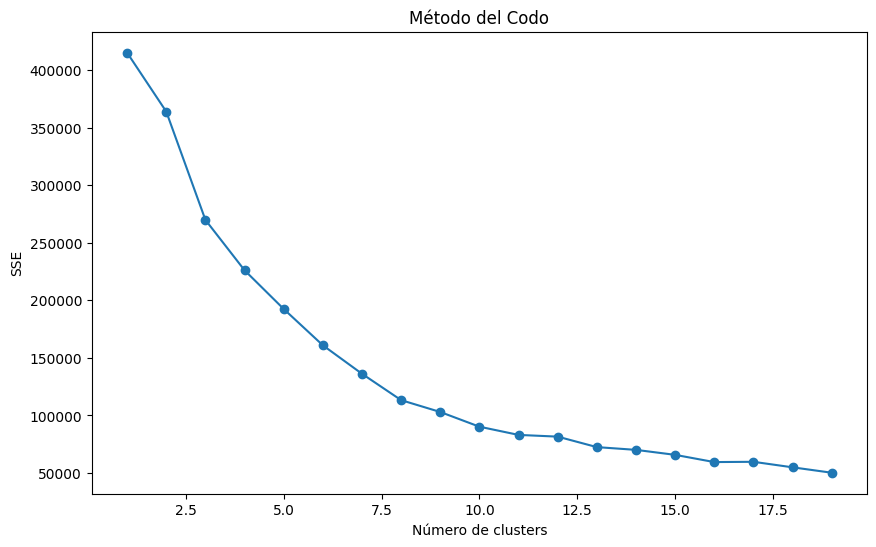

El codo está en k = 8


In [23]:
sse = [] # Aquí guardamos el puntaje de la función objetivo

for k in range(1, 20):
    print(k)
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_monopoly)
    sse.append(kmeans.inertia_)

# Graficar el método del codo para ver la elección de k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), sse, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("SSE")
plt.title("Método del Codo")
plt.show()

kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")

print("El codo está en k =", kl.elbow)

In [13]:
from sklearn.cluster import KMeans, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=20, init='k-means++', random_state=1)

kmeans.fit(df_monopoly)

labels = kmeans.labels_

centroids = kmeans.cluster_centers_

sse = kmeans.inertia_

print(sse)

46902.02885839255


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


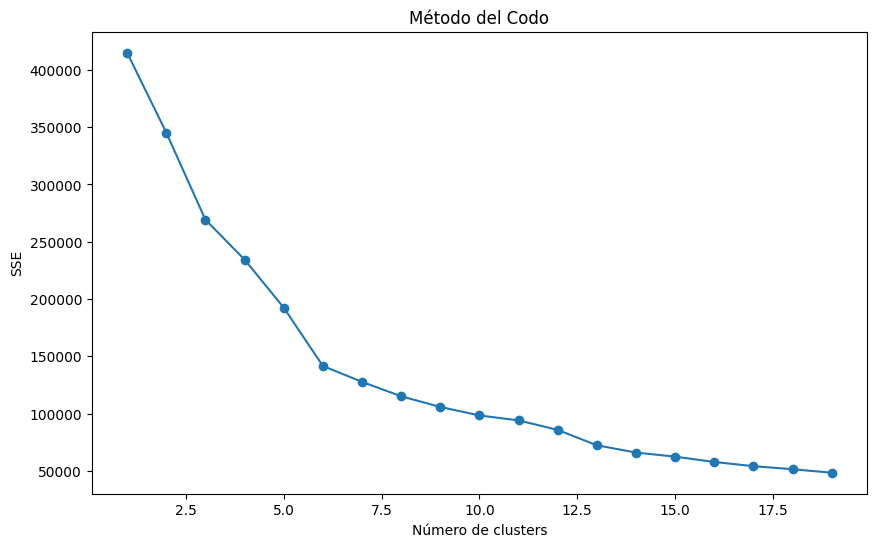

El codo está en k = 6


In [14]:
# Ensure sse is initialized and empty before the loop
sse = []

for k in range(1, 20):
    print(k)
    kkmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    kkmeans.fit(df_monopoly)
    sse.append(kkmeans.inertia_)  # Add the inertia for this k to sse

# Graficar el método del codo para ver la elección de k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), sse, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("SSE")
plt.title("Método del Codo")
plt.show()

# Now use KneeLocator
kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")
print("El codo está en k =", kl.elbow)

In [ ]:
# silhouette_score -> entre más alto mejor
# davies_bouldin_score -> entre más bajo mejor

# Clusters con el algoritmo K-Means (K-medias)
clusters_km = KMeans(n_clusters=6, random_state=1)
clusters_km.fit_predict(df_monopoly)

# Cálculo de métricas para K-Means
silueta_km = silhouette_score(df_monopoly, clusters_km.labels_)
davies_bouldin_km = davies_bouldin_score(df_monopoly, clusters_km.labels_)


In [15]:
# Nos fijamos las etiquetas asignadas a las primeras 10 muestras y los counts que recibió cada una
np.unique(kmeans.labels_[:10], return_counts=True) 

(array([ 2,  4,  8,  9, 13, 14, 15, 17, 19]),
 array([1, 1, 1, 1, 2, 1, 1, 1, 1], dtype=int64))

In [16]:
# Guardo las posiciones de los centroids
centroids = kmeans.cluster_centers_

# Muestro las dimensiones de las posiciones
print("Shape de los centroids:",centroids.shape)
# Printeo las posiciones de las primeras 5 muestras en sus primeras dos componentes principales
print(centroids[:5])

Shape de los centroids: (20, 12)
[[ 7.64988767e-01 -9.62404706e-01  2.35325677e-01  9.30004902e-01
  -9.29968291e-01 -5.86999538e-01 -3.00250098e-02  5.82867088e-16
  -3.99558746e-01 -2.59662749e-01  1.00000000e+00  2.31676495e-03]
 [ 8.25765394e-01  2.28141898e-01  3.06453750e-01 -1.07524209e+00
   1.07528443e+00 -5.86999538e-01 -3.00250098e-02 -2.99760217e-15
  -3.99558746e-01 -2.59662749e-01  1.00000000e+00  2.88957688e-03]
 [ 8.57043344e-01 -9.82330952e-02  3.71950464e-01  9.30004902e-01
  -9.29968291e-01  1.70354550e+00 -3.00250098e-02 -1.24900090e-15
  -3.99558746e-01 -2.59662749e-01  2.08173375e+00  3.71517028e-03]
 [ 7.93207283e-01  7.31647069e-01  3.08456435e-01  9.30004902e-01
  -9.29968291e-01 -5.86999538e-01 -3.00250098e-02  2.70378151e-01
   2.50271187e+00 -2.59662749e-01  2.08151261e+00  1.00000000e+00]
 [ 8.93008130e-01 -3.26543153e-01  3.36261874e-01 -1.07524209e+00
   1.07528443e+00  1.70354550e+00 -3.00250098e-02  7.07767178e-16
  -3.99558746e-01 -2.59662749e-01  2.10

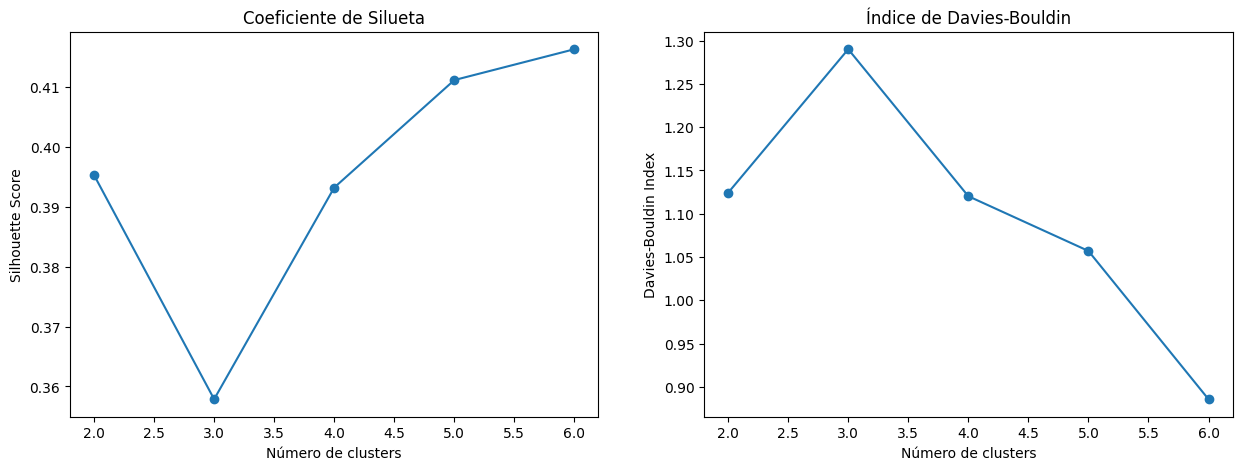

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Supongamos que `df_monopoly` es tu DataFrame y ya está preprocesado
df_monopoly_array = df_monopoly.to_numpy()

silhouette_scores = []  # Coeficiente de Silueta
davies_bouldin_scores = []  # Índice de Davies-Bouldin

# Evaluar para k en el rango de 1 a 6
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df_monopoly_array)
    
    # Métricas
    silhouette_scores.append(silhouette_score(df_monopoly_array, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_monopoly_array, labels))

# Graficar Coeficiente de Silueta y Davies-Bouldin
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Coeficiente de Silueta
ax[0].plot(range(2, 7), silhouette_scores, marker='o')
ax[0].set_title('Coeficiente de Silueta')
ax[0].set_xlabel('Número de clusters')
ax[0].set_ylabel('Silhouette Score')

# Índice de Davies-Bouldin
ax[1].plot(range(2, 7), davies_bouldin_scores, marker='o')
ax[1].set_title('Índice de Davies-Bouldin')
ax[1].set_xlabel('Número de clusters')
ax[1].set_ylabel('Davies-Bouldin Index')

plt.show()


In [23]:
import pandas as pd
from sklearn.decomposition import PCA

# Supongamos que `df_monopoly` es tu DataFrame ya procesado
df_monopoly_array = df_monopoly.to_numpy()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
df_monopoly_pca = pca.fit_transform(df_monopoly_array)

# Obtener las cargas (pesos) de las características en los componentes principales
pca_components = pca.components_

# Crear un DataFrame para visualizar las cargas
pca_df = pd.DataFrame(pca_components, columns=df_monopoly.columns, index=['Componente Principal 1', 'Componente Principal 2'])
print(pca_df)


                          Region     Renta      Edad    Hombre     Mujer  \
Componente Principal 1  0.001801  0.199819  0.011224  0.654036 -0.654035   
Componente Principal 2  0.022519  0.218188  0.024445 -0.253026  0.253048   

                        Adicional   Consumo   Cuentas  Hipotecario  \
Componente Principal 1   0.221022  0.014492  0.014194     0.126706   
Componente Principal 2   0.633003  0.010673  0.047547     0.219882   

                        Monoproducto        TC  Dualidad  
Componente Principal 1     -0.042739  0.186843  0.048632  
Componente Principal 2     -0.019218  0.587669  0.161536  


In [ ]:
sse = [] # Aquí guardamos el puntaje de la función objetivo

for k in range(1, 20):
    print(k)
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    kmeans.fit(df_monopoly_pca)
    sse.append(kmeans.inertia_)

# Graficar el método del codo para ver la elección de k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), sse, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("SSE")
plt.title("Método del Codo")
plt.show()

# Now use KneeLocator
kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")
print("El codo está en k =", kl.elbow)

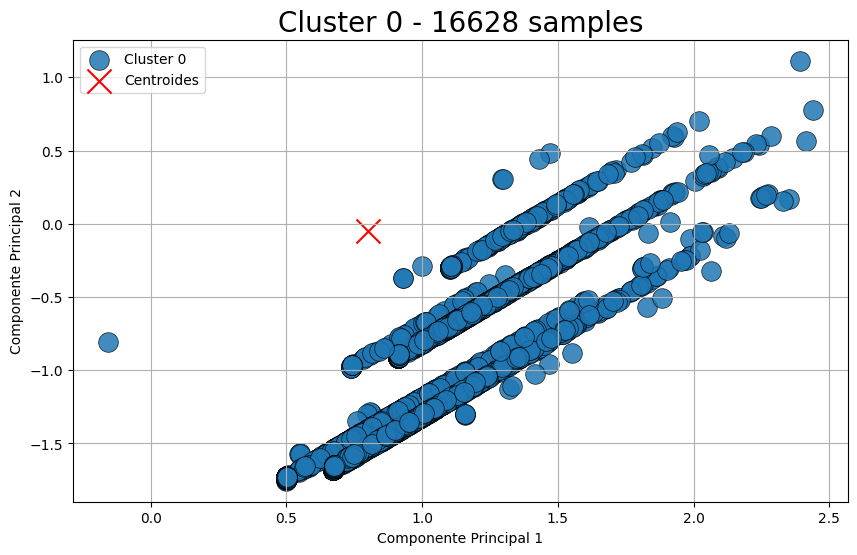

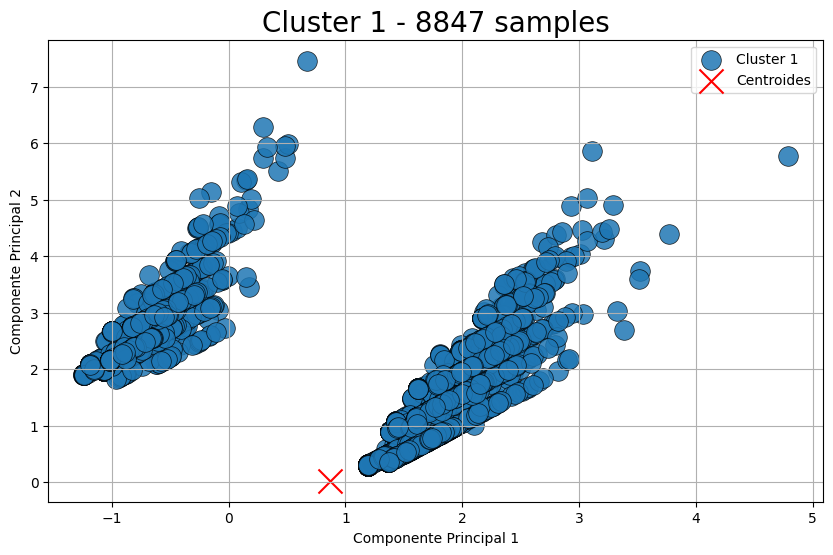

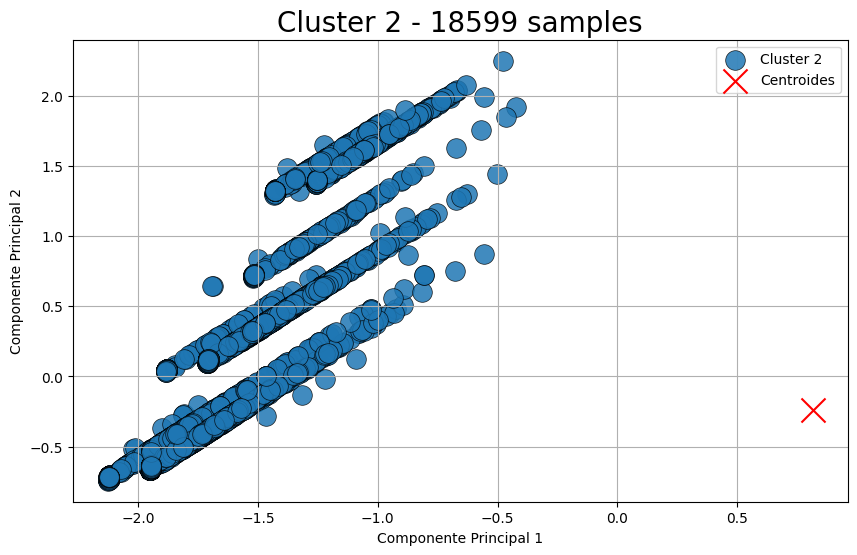

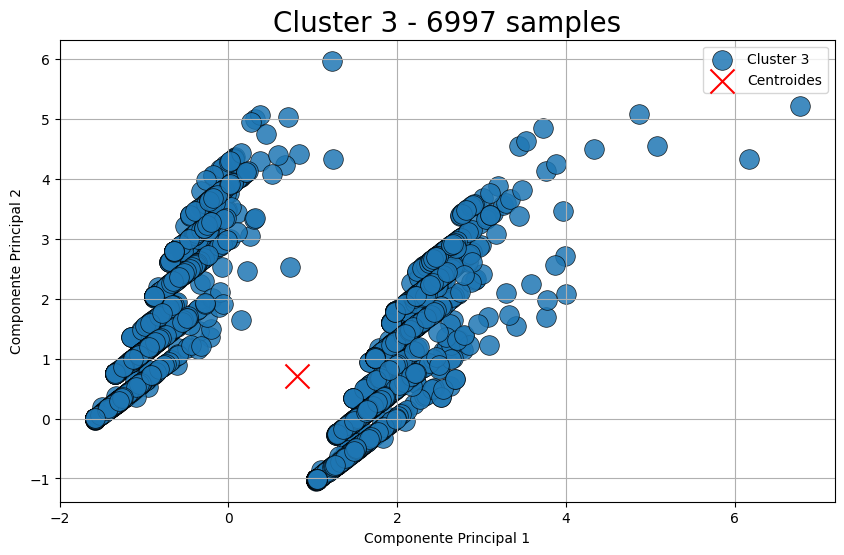

In [32]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# Supongamos que df_monopoly ya está procesado y listo para usar
df_monopoly_array = df_monopoly.to_numpy()

# Número óptimo de clusters determinado previamente (por ejemplo, k_optimal = 6)
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=1)
kmeans.fit(df_monopoly_array)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales para visualización
pca = PCA(n_components=2)
df_monopoly_pca = pca.fit_transform(df_monopoly_array)

# Visualizar los clusters en el espacio de las dos componentes principales
unique_labels = np.unique(labels)
for i in unique_labels:
    index = np.nonzero(labels == i)[0]  # Índices correspondientes a la i-ésima etiqueta
    num = len(index)  # Número de muestras en cada cluster
    
    if num > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(df_monopoly_pca[index, 0], df_monopoly_pca[index, 1], s=200, 
                   linewidth=0.5, edgecolors="black", alpha=0.85, label=f'Cluster {i}')
        ax.scatter(centroids[i, 0], centroids[i, 1], s=300, c='red', marker='x', label='Centroides')
        ax.set_title(f"Cluster {i} - {num} samples", fontsize=20)
        ax.legend()
        ax.set_xlabel("Componente Principal 1")
        ax.set_ylabel("Componente Principal 2")
        ax.grid(True)
        
    plt.show()


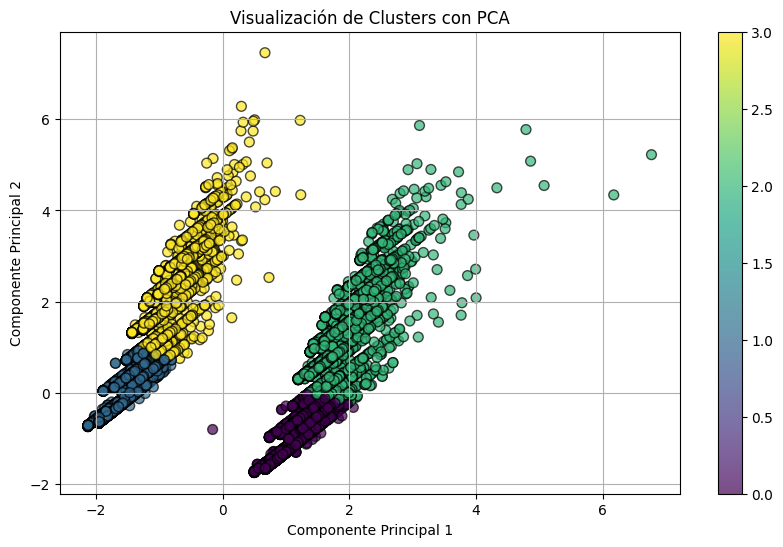

In [30]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Supongamos que `df_monopoly` es tu DataFrame ya procesado
df_monopoly_array = df_monopoly.to_numpy()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
df_monopoly_pca = pca.fit_transform(df_monopoly_array)

# Ajustar K-means al DataFrame reducido
k_optimal = 4  # Valor óptimo determinado previamente
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=1)
kmeans.fit(df_monopoly_pca)
labels = kmeans.labels_

# Visualizar todos los datos en un gráfico, coloreados por cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_monopoly_pca[:, 0], df_monopoly_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.colorbar(scatter)
plt.title("Visualización de Clusters con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()


In [20]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

InvalidIndexError: (slice(None, None, None), 0)

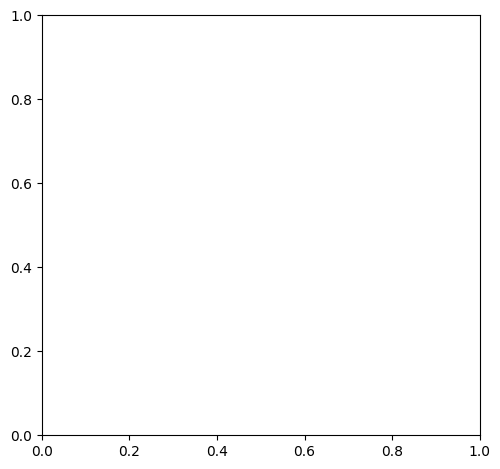

In [21]:
fig = plt.figure(figsize=(26, 12))

for k in range(2, 10):
    # Creación de clusters
    clusters = kmeans
    clusters.fit_predict(df_monopoly)
    # Cálculo de métricas 
    silueta = silhouette_score(df_monopoly, clusters.labels_)
    davies_bouldin = davies_bouldin_score(df_monopoly, clusters.labels_)
    # Graficando clusters
    ax = fig.add_subplot(2, 4, k-1)
    ax.scatter(df_monopoly[clusters.labels_>=0][:, 0], df_monopoly[clusters.labels_>=0][:, 1], 
               c=clusters.labels_[clusters.labels_>=0], s=200, 
               linewidth=0.5, edgecolors="black", alpha=0.85)
    ax.set_title("\n\nSilueta = %.2f \n Davies-Bouldin = %.2f" % 
                 (silueta, davies_bouldin), fontsize=20)
    ax.axis("off")
    
plt.show()